In [2]:
# pandas (pd): عشان نتعامل مع الجداول والبيانات
import pandas as pd
# seaborn (sns): عشان نرسم رسومات بيانية جميلة
import seaborn as sns
# numpy (np): عشان عمليات رياضية على الأرقام والمصفوفات
import numpy as np
# matplotlib.pyplot (plt): عشان نرسم رسوم بيانية يدويًا
import matplotlib.pyplot as plt
# Pipeline: يسهل ربط أكثر من خطوة معالجة مع بعض (مثلاً تنظيف البيانات + تدريب النموذج)
from sklearn.pipeline import Pipeline
# ColumnTransformer: تعالج أعمدة معينة بطريقة خاصة (زي تطبيع أرقام أو تحويل نصوص)
from sklearn.compose import ColumnTransformer
# train_test_split: تقسم البيانات إلى جزء للتدريب وجزء للاختبار
from sklearn.model_selection import train_test_split
# StandardScaler: تطبع الأرقام عشان تكون بنفس النطاق (مثلاً كلهم من 0 لـ 1 أو -1 لـ 1)
# OneHotEncoder: يحول القيم النصية (زي "ذكر" و"أنثى") إلى أرقام يفهمها النموذج
from sklearn.preprocessing import OneHotEncoder
# LogisticRegression: خوارزمية مشهورة لتوقع إذا كان الشيء "نعم أو لا" (مريض أو غير مريض مثلاً)
from sklearn.linear_model import LogisticRegression
# classification_report و confusion_matrix: عشان نقيم أداء النموذج (نشوف نسبة الصح والخطأ)
from sklearn.metrics import classification_report, confusion_matrix
# SimpleImputer: يحل مشكلة القيم الناقصة (لو فيه بيانات ناقصة يعوضها)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
# pd.read_csv(file_path) يقرأ الملف ويخزنه في متغير اسمه df (وهو اختصار لـ DataFrame = جدول بيانات)
file_path = r"C:\Users\Mobily\Downloads\heart_disease_uci.csv"
df = pd.read_csv(file_path)

In [3]:
# Created an imputer object
# Instructed it: if there are missing values in numeric columns, fill them with the column mean
imputer = SimpleImputer(strategy='mean')
# Selected only the numeric columns from the df table
# Processed them with the imputer (filled missing values with the mean)
# Stored the result in a new table df_imputed with the same columns but no missing values
df_imputed = pd.DataFrame(imputer.fit_transform(df.select_dtypes(include=[np.number])), columns=df.select_dtypes(include=[np.number]).columns)
# Returned the cleaned results (df_imputed) back into the original df
# Now the numeric columns are clean
df[df_imputed.columns] = df_imputed
# Created a new column named num
# If there's any sign of disease (target > 0) → it becomes 1 (means "sick")
# If no disease (target == 0) → it becomes 0 (means "healthy")
df['num'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
# Deleted the column num since we’ll be using target later as the classification label (no need for duplication)
df.drop('num', axis=1, inplace=True)
# Prints the number of missing values in each column, to ensure everything is fine before feeding the data to the model
print("\nNumber of missing values after cleaning:")
print(df.isnull().sum())



Number of missing values after cleaning:
id               0
age              0
gender           0
dataset          0
cp               0
trestbps         0
chol             0
fbs             90
restecg          2
thalach          0
exang           55
oldpeak          0
slope          309
ca               0
thal           486
target           0
Unnamed: 16    919
dtype: int64


In [4]:
# عشان تبين الفرق بين الناس اللي أعمارهم عالية وعندهم مرض، وبين اللي ما عندهم
# تسهيل التحليل ومعرفة تأثير الفئات العمرية
bins = [0, 40, 55, 70, 100]
labels = ['<40', '40-55', '55-70', '70+']
df['age_category'] = pd.cut(df['age'], bins=bins, labels=labels)
# إنشاء تفاعل بين العمر والمرض
# إبراز العلاقة بين تقدم العمر واحتمالية المرض
df['age_sex_interaction'] = df['age'] * df['target']

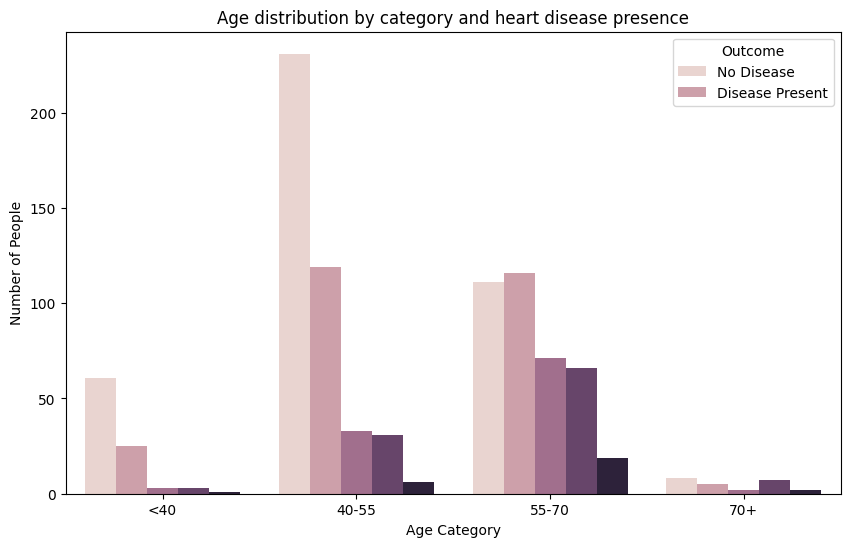

In [5]:
# تحديد حجم الرسم البياني ليكون 10 وحدات عرضًا و6 وحدات طولًا
plt.figure(figsize=(10, 6))
# رسم مخطط عدّي يُظهر عدد الأشخاص في كل فئة عمرية مع تمييز الأشخاص حسب وجود مرض القلب (باستخدام hue)
sns.countplot(data=df, x='age_category', hue='target')
# إضافة عنوان يوضح محتوى الرسم البياني
plt.title('Age distribution by category and heart disease presence')
# تسمية المحور الأفقي ليكون "فئة العمر"
plt.xlabel('Age Category')
# تسمية المحور العمودي ليكون "عدد الأشخاص"
plt.ylabel('Number of People')
# إضافة أسطورة تشرح الألوان المستخدمة في الرسم (أي لون يمثل المرض وأي لون لا)
plt.legend(title='Outcome', labels=['No Disease', 'Disease Present'])
# عرض الرسم البياني النهائي على الشاشة
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# مثال لتعريف الأعمدة الرقمية
numeric_features = ['age', 'income']
numeric_transformer = StandardScaler()

# الأعمدة الفئوية (Categorical)
categorical_features = ['gender', 'city']
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# المعالج العام
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [7]:
# افترض أن عندك DataFrame اسمه df
X = df.drop('target', axis=1) # حذف العمود الهدف
y = df['target'] # تحديد العمود الهدف

In [8]:
# حذف الأعمدة الغير مفيدة
df = df.drop(columns=['id', 'Unnamed: 16'], errors='ignore')

# تحديد المتغير الهدف
X = df.drop('target', axis=1)
y = df['target']

# الأعمدة الرقمية
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'age_sex_interaction']

# الأعمدة الفئوية
categorical_features = ['gender', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category']

# معالجات الأعمدة
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# المعالجة المبدئية
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# بايبلاين كامل مع موديل
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب الموديل
pipeline.fit(X_train, y_train)

# التنبؤ
y_pred = pipeline.predict(X_test)

# تقييم الأداء
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        75
         1.0       0.96      1.00      0.98        54
         2.0       0.92      0.88      0.90        25
         3.0       0.89      0.92      0.91        26
         4.0       1.00      0.50      0.67         4

    accuracy                           0.96       184
   macro avg       0.95      0.86      0.89       184
weighted avg       0.96      0.96      0.96       184



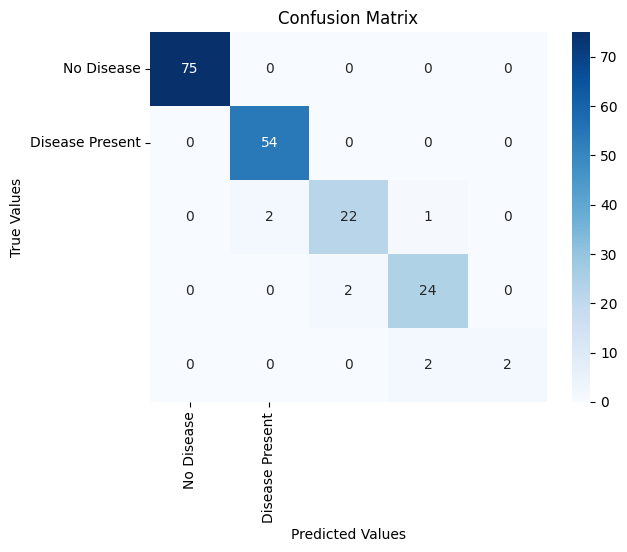

In [9]:
# confusion_matrix(): هذه دالة من مكتبة Scikit-learn تُستخدم لإنشاء مصفوفة الارتباك
# مصفوفة الارتباك هي أداة لتقييم أداء نموذج التصنيف عن طريق مقارنة القيم الحقيقية (في هذه الحالة y_test) مع القيم المتنبأ بها (y_pred).
conf_matrix = confusion_matrix(y_test, y_pred)
# sns.heatmap(): هذه دالة من مكتبة Seaborn تُستخدم لعرض البيانات على شكل مخطط حراري (Heatmap)
# conf_matrix: المصفوفة التي تحتوي على نتائج الارتباك (عدد الحالات)
# annot=True: هذا يضمن أن القيم داخل المصفوفة ستظهر داخل الخلايا
# fmt='d': هذه المعلمة تحدد أن القيم المعروضة ستكون أعدادًا صحيحة (d يعني integer)
# cmap='Blues': يحدد الألوان المستخدمة في المخطط الحراري. في هذه الحالة يتم استخدام ألوان تتدرج من الأزرق
# xticklabels و yticklabels: تحدد تسميات المحاور (التي تكون فئات "لا يوجد مرض" و "يوجد مرض")
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease Present'],
            yticklabels=['No Disease', 'Disease Present'])
# plt.title(): يضيف عنوانًا إلى المخطط الحراري (هنا العنوان هو "مصفوفة الارتباك")
# plt.ylabel(): يضيف تسمية للمحور العمودي (هنا "القيم الحقيقية").
# plt.xlabel(): يضيف تسمية للمحور الأفقي (هنا "القيم المتنبأ بها")
# plt.show(): يعرض المخطط الحراري على الشاشة
plt.title('Confusion Matrix')
plt.ylabel('True Values')
plt.xlabel('Predicted Values')
plt.show()

In [10]:
# 1. استيراد المكتبات اللازمة
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd

# 2. حمّل بياناتك الأصلية إذا لم تكن محملة بالفعل
# (استبدل هذا بكود تحميل بياناتك الفعلية)
try:
    # تحقق من وجود البيانات الأصلية
    X_train.shape  # هذا سيسبب خطأ إذا كان X_train غير موجود
except NameError:
    print("Loading original data...")
    # هنا يمديك تحمل بياناتك الأصلية
    # مثال: 
    # data = pd.read_csv('your_data.csv')
    # X = data.drop('target', axis=1)
    # y = data['target']
    # from sklearn.model_selection import train_test_split
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # أو تحميل بيانات مُعدة مسبقًا:
    # X_train = pd.read_csv('X_train.csv')
    # X_test = pd.read_csv('X_test.csv')
    # y_train = pd.read_csv('y_train.csv')
    # y_test = pd.read_csv('y_test.csv')

# 3. تحديد الأعمدة الرقمية والفئوية (قم بتعديلها حسب بيانانك)
numeric_features = []  # أدخل أسماء الأعمدة الرقمية هنا
categorical_features = []  # أدخل أسماء الأعمدة الفئوية هنا

# إذا لم تكن متأكدًا من أنواع الأعمدة، يمكنك تحديدها تلقائيًا:
for column in X_train.columns:
    if X_train[column].dtype in ['int64', 'float64']:
        numeric_features.append(column)
    else:
        categorical_features.append(column)

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

# 4. إنشاء خط المعالجة
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# 5. تطبيق خط المعالجة على البيانات
print("Applying preprocessing pipeline...")
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

# 6. عرض شكل البيانات المعالجة
print("\nShape of training data after preprocessing:", X_train_processed.shape)
print("Shape of test data after preprocessing:", X_test_processed.shape)

# 7. حفظ البيانات المعالجة
np.save('X_train_processed.npy', X_train_processed)
np.save('X_test_processed.npy', X_test_processed)

# حفظ متغيرات الهدف
try:
    np.save('y_train.npy', y_train.values)
    np.save('y_test.npy', y_test.values)
except AttributeError:
    # في حالة كان y_train و y_test عبارة عن arrays وليس DataFrames
    np.save('y_train.npy', y_train)
    np.save('y_test.npy', y_test)

print("\nPreprocessing complete and data saved!")

Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'age_sex_interaction']
Categorical columns: ['gender', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category']
Applying preprocessing pipeline...

Shape of training data after preprocessing: (736, 34)
Shape of test data after preprocessing: (184, 34)

Preprocessing complete and data saved!


In [11]:
# التحقق من الأعمدة الرقمية
for feature in numeric_features:
    if feature not in df.columns:
        print(f"Column {feature} is not found in the DataFrame!")


# التحقق من الأعمدة الفئوية
for feature in categorical_features:
    if feature not in df.columns:
        print(f"Column {feature} is not found in the DataFrame!")


# تحديث القوائم بإزالة الأعمدة غير المتوافقة
numeric_features = [feature for feature in numeric_features if feature in df.columns]
categorical_features = [feature for feature in categorical_features if feature in df.columns]

# عرض القوائم المحدثة
print("Compatible numeric features:", numeric_features)
print("Compatible categorical features:", categorical_features)

Compatible numeric features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'age_sex_interaction']
Compatible categorical features: ['gender', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_category']


In [12]:
# يتم إنشاء نسخة من أسماء الأعمدة الرقمية في قائمة جديدة feature_names
feature_names = numeric_features.copy()

# إذا كانت هناك أعمدة فئوية، يتم استخراج الأعمدة الناتجة من الترميز الأحادي وإضافتها إلى feature_names
if categorical_features:
    # محاولة الوصول إلى محول OneHotEncoder بطرق مختلفة
    try:
        # طريقة 1: استخدام transformers_
        ohe = preprocessing_pipeline.named_steps['preprocessor'].transformers_[1][1]
    except AttributeError:
        try:
            # طريقة 2: استخدام named_transformers_
            ohe = preprocessing_pipeline.named_steps['preprocessor'].named_transformers_['onehotencoder']
        except (AttributeError, KeyError):
            try:
                # طريقة 3: استخدام transformers بدون شرطة سفلية
                ohe = preprocessing_pipeline.named_steps['preprocessor'].transformers[1][1]
            except (AttributeError, IndexError):
                # طريقة 4: للإصدارات الحديثة جدًا، محاولة استخدام _transformers
                ohe = preprocessing_pipeline.named_steps['preprocessor']._transformers[1][1]
    
    try:
        # محاولة استخدام get_feature_names_out
        cat_feature_names = ohe.get_feature_names_out(categorical_features)
    except AttributeError:
        try:
            # للإصدارات القديمة
            cat_feature_names = ohe.get_feature_names(categorical_features)
        except AttributeError:
            print("Could not automatically extract categorical feature names.")
            cat_feature_names = []
    
    feature_names.extend(cat_feature_names)

# يتم طباعة جميع أسماء الأعمدة بعد المعالجة
print("\nFeature names after preprocessing:")
for i, name in enumerate(feature_names):
    print(f"{i+1}. {name}")


Feature names after preprocessing:
1. age
2. trestbps
3. chol
4. thalach
5. oldpeak
6. ca
7. age_sex_interaction
8. gender_Female
9. gender_Male
10. dataset_Cleveland
11. dataset_Hungary
12. dataset_Switzerland
13. dataset_VA Long Beach
14. cp_asymptomatic
15. cp_atypical angina
16. cp_non-anginal
17. cp_typical angina
18. fbs_False
19. fbs_True
20. restecg_lv hypertrophy
21. restecg_normal
22. restecg_st-t abnormality
23. exang_False
24. exang_True
25. slope_downsloping
26. slope_flat
27. slope_upsloping
28. thal_fixed defect
29. thal_normal
30. thal_reversable defect
31. age_category_40-55
32. age_category_55-70
33. age_category_70+
34. age_category_<40
